# PCR Lab Data – Eksploracyjna Analiza Danych

**Dataset:** PCR Lab Data (Zenodo / iopt community)  
**Format:** XES YAML (eXtensible Event Stream)  
**Kontekst:** System automatyzacji laboratorium PCR – śledzenie próbek od rejestracji do wyniku  

Notebook realizuje **Milestone 1** projektu Business Modeling.

## 0. Importy i konfiguracja

In [19]:
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

DATA_DIR = Path('/mnt/adata-disk/projects/agh/2stopien/BusinessModeling/data')
print(f'Katalog danych: {DATA_DIR}')
yaml_files = sorted(DATA_DIR.glob('*.xes.yaml'))
print(f'Liczba plików YAML: {len(yaml_files)}')

Katalog danych: /mnt/adata-disk/projects/agh/2stopien/BusinessModeling/data
Liczba plików YAML: 6339


## 1. Wczytanie i przetwarzanie danych

In [20]:
%%time

RESULT_MAP = {'N': 'NEGATIVE', 'P': 'POSITIVE', 'NEGATIVE': 'NEGATIVE', 'POSITIVE': 'POSITIVE'}

def normalize_result(val):
    """Normalizuje wynik PCR: obsługuje string ('N','P','NEGATIVE','POSITIVE') i dict."""
    if isinstance(val, dict):
        val = val.get('result', None)
    if isinstance(val, str):
        return RESULT_MAP.get(val.strip().upper(), val)
    return None

def extract_result_from_data(data_list):
    """Wyciąga wynik PCR i wartość ct z listy data elementów."""
    result, ct = None, None
    if not isinstance(data_list, list):
        return result, ct
    for item in data_list:
        if not isinstance(item, dict):
            continue
        if item.get('name') == 'state' and isinstance(item.get('value'), dict):
            state = item['value']
            result = normalize_result(state.get('result'))
            ct = state.get('ct')
        elif item.get('name') == 'result':
            result = normalize_result(item.get('value'))
        elif item.get('name') == 'ct':
            ct = item.get('value')
    return result, ct


def parse_yaml_file(filepath):
    """Parsuje jeden plik XES YAML i zwraca listę słowników (eventów)."""
    events = []
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            docs = list(yaml.safe_load_all(f))

        header = docs[0] if docs else {}
        log_info = header.get('log', {}) if isinstance(header, dict) else {}
        trace_info = log_info.get('trace', {})
        case_name = trace_info.get('cpee:name', '') if isinstance(trace_info, dict) else ''

        instance_uuid = filepath.stem.replace('.xes', '')

        for doc in docs[1:]:
            if not isinstance(doc, dict) or 'event' not in doc:
                continue
            ev = doc['event']

            ts = ev.get('time:timestamp', None)
            if isinstance(ts, str) and ts:
                try:
                    ts = pd.to_datetime(ts, utc=True)
                except:
                    ts = None
            elif hasattr(ts, 'isoformat'):
                ts = pd.to_datetime(ts.isoformat(), utc=True)
            else:
                ts = None

            result, ct = extract_result_from_data(ev.get('data'))

            events.append({
                'case_id': ev.get('concept:instance'),
                'instance_uuid': instance_uuid,
                'case_name': case_name,
                'activity': ev.get('concept:name'),
                'endpoint': ev.get('concept:endpoint', ''),
                'lifecycle': ev.get('lifecycle:transition'),
                'cpee_lifecycle': ev.get('cpee:lifecycle:transition'),
                'cpee_activity_id': ev.get('cpee:activity'),
                'cpee_state': ev.get('cpee:state'),
                'timestamp': ts,
                'result': result,
                'ct': ct,
            })
    except Exception:
        pass
    return events


# Wczytaj wszystkie pliki równolegle
all_events = []
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(parse_yaml_file, f): f for f in yaml_files}
    for future in tqdm(as_completed(futures), total=len(futures), desc='Wczytywanie plików'):
        all_events.extend(future.result())

df_all = pd.DataFrame(all_events)
print(f'\nWczytano {len(df_all):,} eventów z {df_all["instance_uuid"].nunique():,} cases')


Wczytywanie plików:   0%|          | 0/6339 [00:00<?, ?it/s]


Wczytano 317,905 eventów z 6,339 cases
CPU times: user 15min 26s, sys: 8.76 s, total: 15min 35s
Wall time: 15min 41s


In [21]:
# Filtruj do eventów biznesowych: mają concept:name (nie None, nie __INVALID__)
# i lifecycle:transition = start lub complete
INVALID_NAMES = {None, '__INVALID__', 'external'}
BUSINESS_LIFECYCLES = {'start', 'complete'}

df_biz = df_all[
    (~df_all['activity'].isin(INVALID_NAMES)) &
    (df_all['activity'].notna()) &
    (df_all['lifecycle'].isin(BUSINESS_LIFECYCLES))
].copy()

df_biz = df_biz.sort_values(['instance_uuid', 'timestamp']).reset_index(drop=True)

print(f'Eventy biznesowe (start/complete): {len(df_biz):,}')
print(f'Cases z eventami biznesowymi: {df_biz["instance_uuid"].nunique():,}')
print(f'\nSample danych:')
df_biz.head()

Eventy biznesowe (start/complete): 134,099
Cases z eventami biznesowymi: 6,339

Sample danych:


,case_id,instance_uuid,case_name,activity,endpoint,lifecycle,cpee_lifecycle,cpee_activity_id,cpee_state,timestamp,result,ct
0,15143,003effb8-cb6d-468d-a243-a12763e5021c,Sample: 0cca00f1-183f-44a0-a132-b29ec7f34f6e,timeout,https://mygreschner.com/backend/services/timeout2,start,activity/calling,a2,None,2023-05-02 14:17:41.174000+00:00,None,NaN
1,15143,003effb8-cb6d-468d-a243-a12763e5021c,Sample: 0cca00f1-183f-44a0-a132-b29ec7f34f6e,Match patient data,https://mygreschner.com//backend/corr,start,activity/calling,a4,None,2023-05-02 14:17:41.185000+00:00,None,NaN
2,15143,003effb8-cb6d-468d-a243-a12763e5021c,Sample: 0cca00f1-183f-44a0-a132-b29ec7f34f6e,Wait for plate validation,https-get://cpee.org/ing/correlators/message/r...,start,activity/calling,a6,None,2023-05-02 14:17:41.186000+00:00,None,NaN
3,15143,003effb8-cb6d-468d-a243-a12763e5021c,Sample: 0cca00f1-183f-44a0-a132-b29ec7f34f6e,Match patient data,https://mygreschner.com//backend/corr,complete,activity/done,a4,None,2023-05-02 14:17:47.950000+00:00,None,NaN
4,15143,003effb8-cb6d-468d-a243-a12763e5021c,Sample: 0cca00f1-183f-44a0-a132-b29ec7f34f6e,Wait for plate validation,https-get://cpee.org/ing/correlators/message/r...,complete,activity/done,a6,None,2023-05-02 16:45:19.629000+00:00,None,NaN


## 2. Podstawowe statystyki

In [22]:
print('=' * 55)
print('STATYSTYKI PODSTAWOWE – PCR Lab Data')
print('=' * 55)
print(f'Liczba plików (cases):          {len(yaml_files):>8,}')
print(f'Liczba eventów (wszystkich):    {len(df_all):>8,}')
print(f'Liczba eventów (biznesowych):   {len(df_biz):>8,}')
print(f'Unikalne aktywności:            {df_biz["activity"].nunique():>8,}')
print(f'Unikalne endpointy (resources): {df_biz["endpoint"].nunique():>8,}')

min_ts = df_biz['timestamp'].min()
max_ts = df_biz['timestamp'].max()
print(f'\nZakres czasowy:')
print(f'  Od: {min_ts}')
print(f'  Do: {max_ts}')
print(f'  Czas trwania: {(max_ts - min_ts).days} dni')

STATYSTYKI PODSTAWOWE – PCR Lab Data
Liczba plików (cases):             6,339
Liczba eventów (wszystkich):     317,905
Liczba eventów (biznesowych):    134,099
Unikalne aktywności:                  31
Unikalne endpointy (resources):       64

Zakres czasowy:
  Od: 2023-04-02 16:00:01.367000+00:00
  Do: 2023-06-14 07:24:15.779000+00:00
  Czas trwania: 72 dni


In [23]:
# Aktywności i ich liczba
activity_counts = df_biz[df_biz['lifecycle'] == 'start']['activity'].value_counts()
print('Aktywności biznesowe (liczba wywołań):')
print(activity_counts.to_string())

Aktywności biznesowe (liczba wywołań):
activity
Wait for sample                    6310
Match patient data                 6170
Wait for plate validation          6169
timeout                            6168
Spawn per sample flow              6166
Receive sample state               6083
Callback timeout                   5767
Sleep                              1716
Check for unfinished Plates        1713
Send notification                  1229
Export result                       821
Export to EMS                       821
Wait for sample delete              213
Notify plain instance               192
Notify per wellplate subprocess     192
Receive finishids                   189
Spawn Single Wellplate              185
Wait for finished plate             167
Delete: Wait for sample delete      167
Delete: Wait for sample             167
Import EPS File                     165
Validate plate                      164
Send plate validation               163
Stopping spawned sample         

In [24]:
# Wyniki PCR – wyciągnij z eventów zawierających dane
results_raw = df_all[df_all['result'].notna()].drop_duplicates(subset='instance_uuid', keep='last')
result_counts = results_raw['result'].value_counts()
print('Dystrybucja wyników PCR:')
print(result_counts.to_string())
print(f'\nBrak wyniku (nie znaleziono w logu): {len(yaml_files) - len(results_raw)}')

Dystrybucja wyników PCR:
result
NEGATIVE    3174
POSITIVE    2818
IPC            1

Brak wyniku (nie znaleziono w logu): 346


In [25]:
# Wyciągnij ct dla POSITIVE
ct_data = df_all[(df_all['ct'].notna()) & (df_all['ct'] != -1)].copy()
ct_data['ct'] = pd.to_numeric(ct_data['ct'], errors='coerce')
ct_data = ct_data.drop_duplicates(subset='instance_uuid', keep='last')
ct_data = ct_data[ct_data['ct'] > 0]
print(f'Cases z wartością ct > 0: {len(ct_data)}')
print(f'ct: min={ct_data["ct"].min():.2f}, max={ct_data["ct"].max():.2f}, mean={ct_data["ct"].mean():.2f}')

Cases z wartością ct > 0: 2827
ct: min=9.31, max=44.44, mean=26.08


## 3. Analiza jakości danych

In [26]:
print('=' * 50)
print('ANALIZA JAKOŚCI DANYCH')
print('=' * 50)

# Braki w kluczowych polach (eventy biznesowe)
print('\nBraki w eventach biznesowych:')
for col in ['case_id', 'activity', 'timestamp', 'lifecycle', 'endpoint']:
    missing = df_biz[col].isna().sum()
    pct = 100 * missing / len(df_biz)
    print(f'  {col:<20}: {missing:>6,} ({pct:.1f}%)')

# Eventy bez nazwy aktywności (wszystkie eventy)
no_name = df_all[df_all['activity'].isna() | df_all['activity'].isin({'__INVALID__'})]
print(f'\nEventy bez nazwy aktywności: {len(no_name):,} ({100*len(no_name)/len(df_all):.1f}% wszystkich)')

# Cases bez zakończenia
finished_cases = set(df_all[df_all['cpee_state'] == 'finished']['instance_uuid'])
all_cases = set(df_all['instance_uuid'].unique())
no_finish = all_cases - finished_cases
print(f'\nCases bez stanu "finished": {len(no_finish)} ({100*len(no_finish)/len(all_cases):.1f}%)')

# Duplikaty
dup_biz = df_biz.duplicated(subset=['instance_uuid', 'activity', 'lifecycle', 'timestamp']).sum()
print(f'Duplikaty (identyczne event+timestamp): {dup_biz}')

# Cases z brakującymi timestampami
missing_ts = df_biz[df_biz['timestamp'].isna()]['instance_uuid'].nunique()
print(f'Cases z brakującym timestamp w eventach biznesowych: {missing_ts}')

ANALIZA JAKOŚCI DANYCH

Braki w eventach biznesowych:
  case_id             :      0 (0.0%)
  activity            :      0 (0.0%)
  timestamp           :      0 (0.0%)
  lifecycle           :      0 (0.0%)
  endpoint            :      0 (0.0%)

Eventy bez nazwy aktywności: 59,095 (18.6% wszystkich)

Cases bez stanu "finished": 682 (10.8%)
Duplikaty (identyczne event+timestamp): 0
Cases z brakującym timestamp w eventach biznesowych: 0


In [27]:
# Sprawdź cases – każdy powinien mieć start i koniec
case_stats = df_biz.groupby('instance_uuid').agg(
    n_events=('activity', 'count'),
    n_activities=('activity', 'nunique'),
    first_ts=('timestamp', 'min'),
    last_ts=('timestamp', 'max'),
).reset_index()

case_stats['duration_min'] = (case_stats['last_ts'] - case_stats['first_ts']).dt.total_seconds() / 60

# Dodaj wynik PCR do case_stats
result_map = results_raw.set_index('instance_uuid')['result'].to_dict()
case_stats['pcr_result'] = case_stats['instance_uuid'].map(result_map)

print(f'Cases z co najmniej 1 eventem biznesowym: {len(case_stats)}')
print(f'\nStatystyki liczby eventów na case:')
print(case_stats['n_events'].describe().round(1).to_string())

Cases z co najmniej 1 eventem biznesowym: 6339

Statystyki liczby eventów na case:
count     6339.0
mean        21.2
std        406.7
min          3.0
25%         10.0
50%         10.0
75%         12.0
max      31838.0


## 4. Eksploracyjna Analiza Danych (EDA)

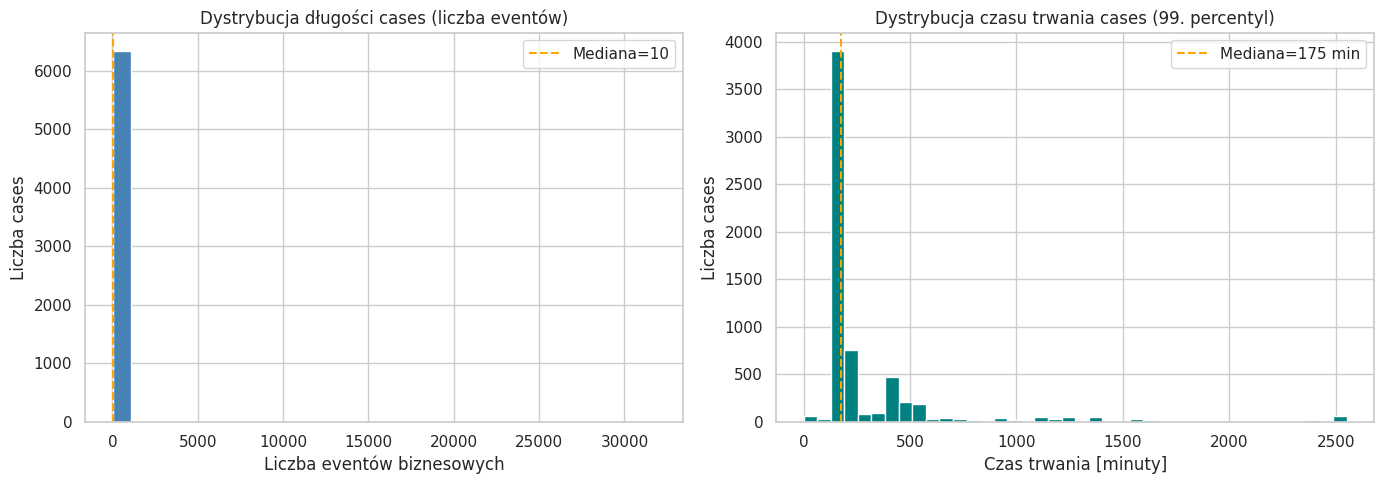

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram liczby eventów na case
axes[0].hist(case_stats['n_events'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Liczba eventów biznesowych')
axes[0].set_ylabel('Liczba cases')
axes[0].set_title('Dystrybucja długości cases (liczba eventów)')
axes[0].axvline(case_stats['n_events'].median(), color='orange', linestyle='--', label=f'Mediana={case_stats["n_events"].median():.0f}')
axes[0].legend()

# Histogram czasu trwania cases
dur_filtered = case_stats[case_stats['duration_min'] < case_stats['duration_min'].quantile(0.99)]['duration_min']
axes[1].hist(dur_filtered, bins=40, color='teal', edgecolor='white')
axes[1].set_xlabel('Czas trwania [minuty]')
axes[1].set_ylabel('Liczba cases')
axes[1].set_title('Dystrybucja czasu trwania cases (99. percentyl)')
axes[1].axvline(dur_filtered.median(), color='orange', linestyle='--', label=f'Mediana={dur_filtered.median():.0f} min')
axes[1].legend()

plt.tight_layout()
plt.savefig('/mnt/adata-disk/projects/agh/2stopien/BusinessModeling/fig_case_distributions.png', dpi=120)
plt.show()

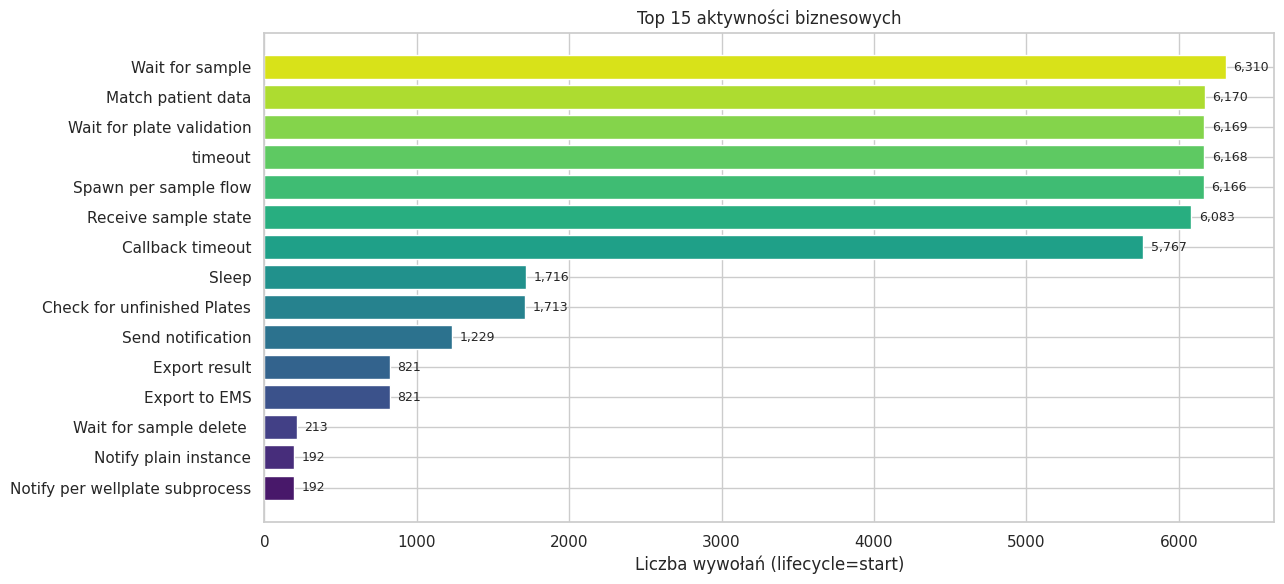

In [29]:
# Top aktywności – wykres słupkowy
top_acts = df_biz[df_biz['lifecycle'] == 'start']['activity'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top_acts.index[::-1], top_acts.values[::-1], color=sns.color_palette('viridis', len(top_acts)))
ax.set_xlabel('Liczba wywołań (lifecycle=start)')
ax.set_title('Top 15 aktywności biznesowych')
for bar, val in zip(bars, top_acts.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/mnt/adata-disk/projects/agh/2stopien/BusinessModeling/fig_top_activities.png', dpi=120)
plt.show()

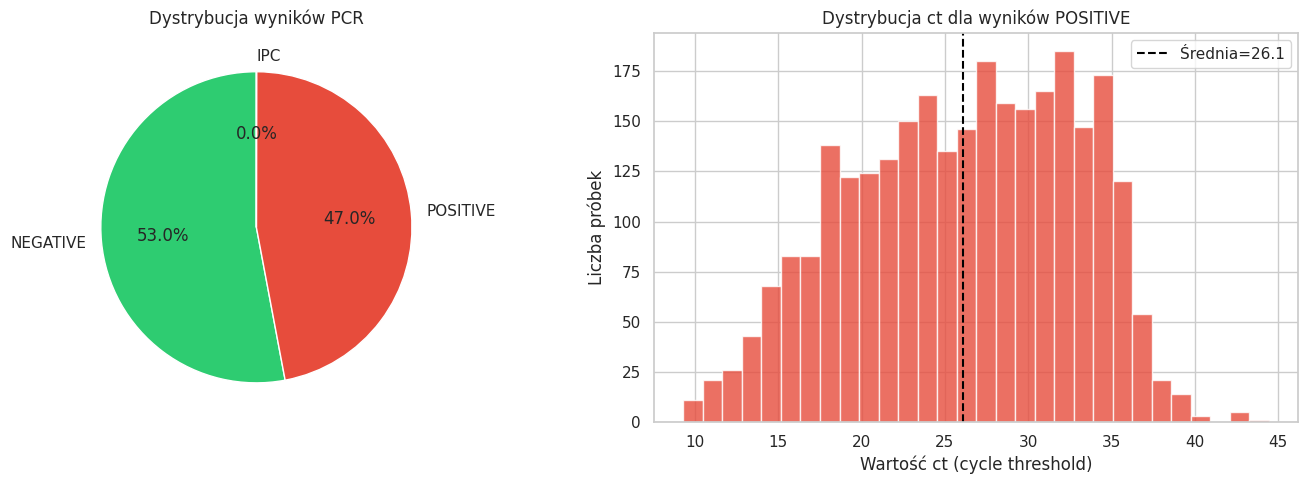

In [30]:
# Wyniki PCR – wykres kołowy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_pie = ['#2ecc71', '#e74c3c', '#95a5a6']
wedges, texts, autotexts = axes[0].pie(
    result_counts.values,
    labels=result_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie[:len(result_counts)],
    startangle=90
)
axes[0].set_title('Dystrybucja wyników PCR')

# Dystrybucja ct dla POSITIVE
ct_vals = ct_data['ct'].dropna()
axes[1].hist(ct_vals, bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Wartość ct (cycle threshold)')
axes[1].set_ylabel('Liczba próbek')
axes[1].set_title('Dystrybucja ct dla wyników POSITIVE')
axes[1].axvline(ct_vals.mean(), color='black', linestyle='--', label=f'Średnia={ct_vals.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('/mnt/adata-disk/projects/agh/2stopien/BusinessModeling/fig_pcr_results.png', dpi=120)
plt.show()

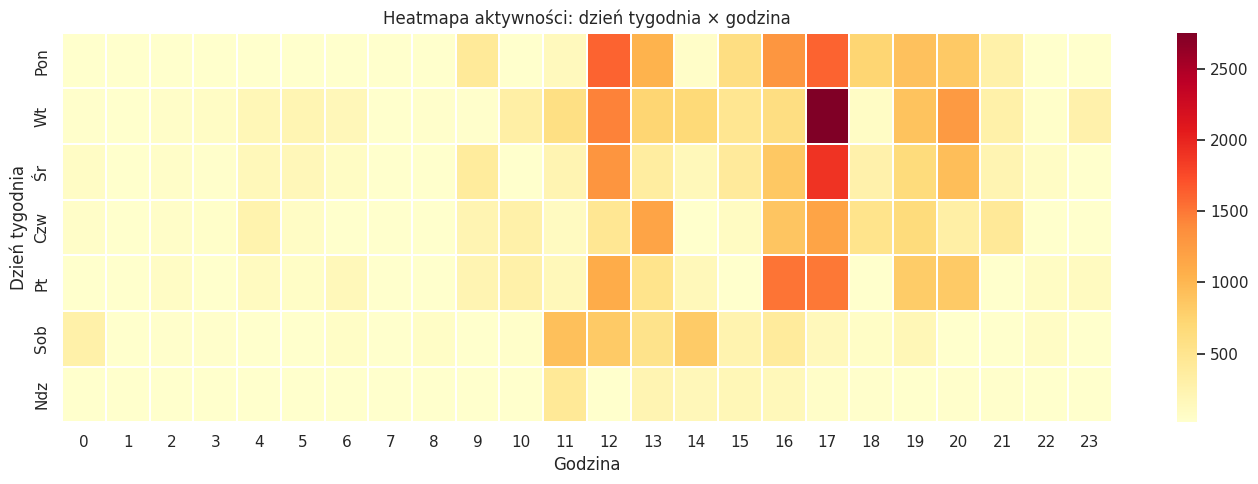

In [31]:
# Heatmapa aktywności: dzień tygodnia × godzina
df_start = df_biz[df_biz['lifecycle'] == 'start'].copy()
df_start['hour'] = df_start['timestamp'].dt.hour
df_start['dayofweek'] = df_start['timestamp'].dt.dayofweek
day_names = ['Pon', 'Wt', 'Śr', 'Czw', 'Pt', 'Sob', 'Ndz']

heat_data = df_start.groupby(['dayofweek', 'hour']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat_data, ax=ax, cmap='YlOrRd', linewidths=0.3,
            xticklabels=range(24), yticklabels=day_names)
ax.set_xlabel('Godzina')
ax.set_ylabel('Dzień tygodnia')
ax.set_title('Heatmapa aktywności: dzień tygodnia × godzina')
plt.tight_layout()
plt.savefig('/mnt/adata-disk/projects/agh/2stopien/BusinessModeling/fig_heatmap_activity.png', dpi=120)
plt.show()

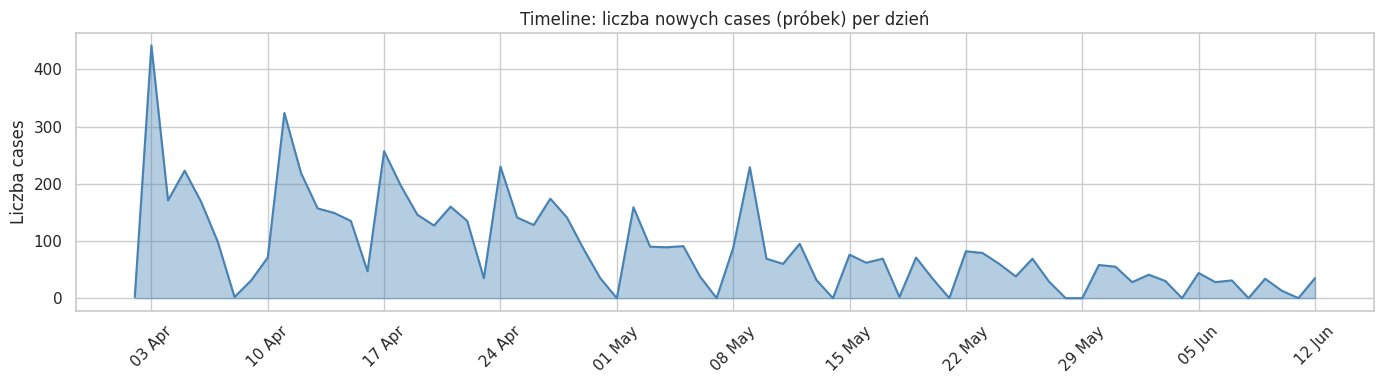

In [32]:
# Timeline: liczba nowych cases per dzień
case_timeline = case_stats.set_index('first_ts').resample('D')['instance_uuid'].count()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(case_timeline.index, case_timeline.values, alpha=0.4, color='steelblue')
ax.plot(case_timeline.index, case_timeline.values, color='steelblue', linewidth=1.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=45)
ax.set_ylabel('Liczba cases')
ax.set_title('Timeline: liczba nowych cases (próbek) per dzień')
plt.tight_layout()
plt.savefig('/mnt/adata-disk/projects/agh/2stopien/BusinessModeling/fig_timeline.png', dpi=120)
plt.show()

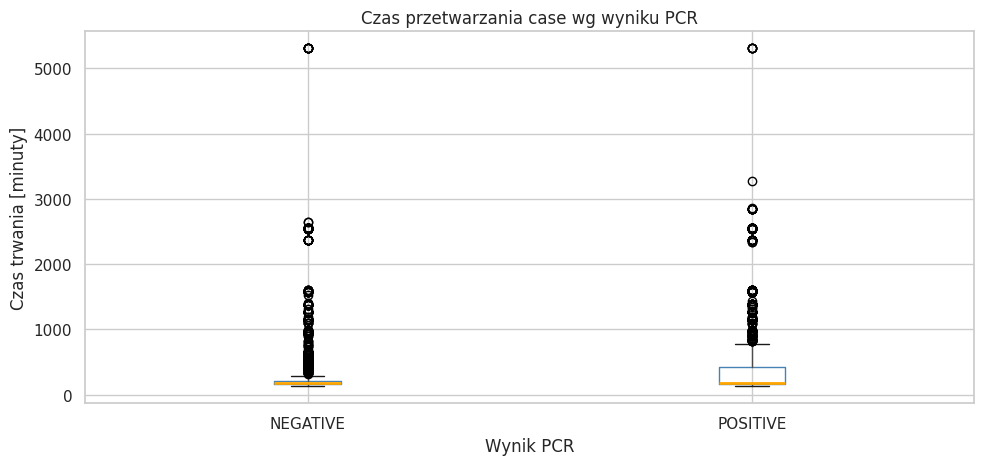


Statystyki czasu [min] wg wyniku:
             count   mean    std    min    25%    50%    75%     max
pcr_result                                                          
NEGATIVE    3174.0  317.6  470.7  125.3  157.0  171.9  212.8  5308.9
POSITIVE    2818.0  357.3  467.6  125.4  161.9  182.9  420.0  5309.7


In [33]:
# Czas trwania cases wg wyniku PCR
cs_result = case_stats[case_stats['pcr_result'].isin(['POSITIVE', 'NEGATIVE']) & (case_stats['duration_min'] > 0)]

fig, ax = plt.subplots(figsize=(10, 5))
cs_result.boxplot(column='duration_min', by='pcr_result', ax=ax, 
                  boxprops=dict(color='steelblue'),
                  medianprops=dict(color='orange', linewidth=2))
ax.set_ylabel('Czas trwania [minuty]')
ax.set_xlabel('Wynik PCR')
ax.set_title('Czas przetwarzania case wg wyniku PCR')
plt.suptitle('')  # usuń nadmiarowy tytuł
plt.tight_layout()
plt.savefig('/mnt/adata-disk/projects/agh/2stopien/BusinessModeling/fig_duration_by_result.png', dpi=120)
plt.show()

print('\nStatystyki czasu [min] wg wyniku:')
print(cs_result.groupby('pcr_result')['duration_min'].describe().round(1).to_string())

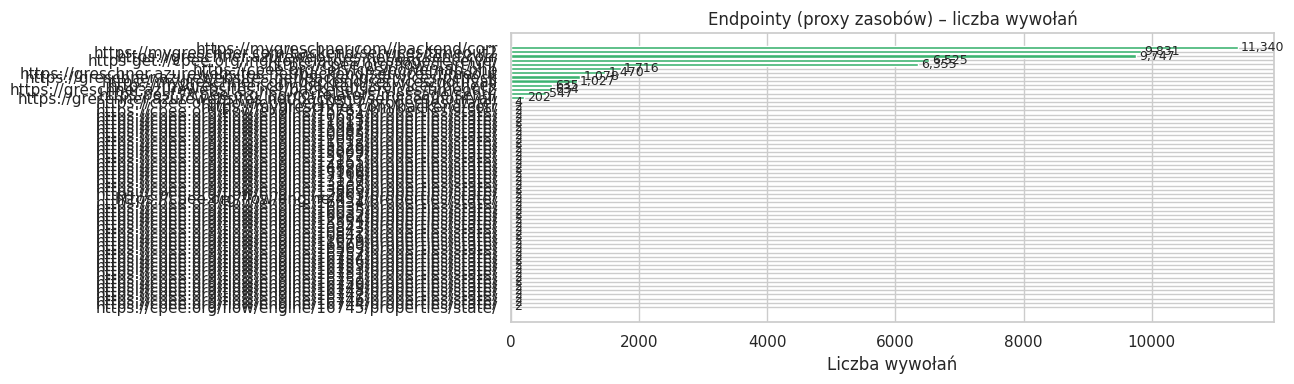

In [34]:
# Endpointy jako proxy zasobów
endpoint_counts = df_biz[df_biz['lifecycle'] == 'start']['endpoint'].value_counts()
endpoint_counts = endpoint_counts[endpoint_counts.index != '']

fig, ax = plt.subplots(figsize=(13, 4))
ax.barh(endpoint_counts.index[::-1], endpoint_counts.values[::-1], color='mediumseagreen')
ax.set_xlabel('Liczba wywołań')
ax.set_title('Endpointy (proxy zasobów) – liczba wywołań')
for i, (idx, val) in enumerate(zip(endpoint_counts.index[::-1], endpoint_counts.values[::-1])):
    ax.text(val + 50, i, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/mnt/adata-disk/projects/agh/2stopien/BusinessModeling/fig_endpoints.png', dpi=120)
plt.show()

## 5. Ocena przydatności datasetu dla milestones

### Kontekst systemu

Dataset pochodzi z **systemu automatyzacji laboratorium PCR** (prawdopodobnie diagnostyka COVID-19). Każdy plik = jeden **case** = jedna próbka pacjenta przechodząca przez pipeline laboratoryjny. System jest oparty na frameworku CPEE (Cloud Process Execution Engine) i rejestruje każde wywołanie serwisu webowego.

| Atrybut XES | Pole w danych | Dostępność |
|---|---|---|
| **Case ID** | `concept:instance` (numeryczny) / `cpee:instance` (UUID) | ✅ Obecny |
| **Activity** | `concept:name` | ✅ Obecny (~30 aktywności) |
| **Timestamp** | `time:timestamp` | ✅ Obecny (ISO 8601 z TZ) |
| **Lifecycle** | `lifecycle:transition` (start/complete) | ✅ Obecny |
| **Resource** | `concept:endpoint` (URL serwisu) | ⚠️ Proxy – brak osoby/maszyny |

---

### Milestone 1: Zrozumienie zbioru danych ✅

- ✅ Opis systemu i kontekstu: zautomatyzowany pipeline PCR w laboratorium
- ✅ Liczba przypadków: ~6 339, eventów: ~260k, aktywności: ~30
- ✅ Identyfikacja kluczowych atrybutów: case_id, activity, timestamp – wszystkie są
- ⚠️ Resource: brak bezpośredniego (endpoint jako proxy)
- ✅ Analiza jakości: brakujące wartości, duplikaty możliwe do sprawdzenia
- ✅ Podstawowe statystyki i wizualizacje: gotowe w tym notebooku

### Milestone 2: Eksploracja i analiza cech ✅

- ✅ Czyszczenie i normalizacja: odfiltrowuj eventy systemowe CPEE
- ✅ Analiza outlierów: cases z ekstremalnie długim/krótkim czasem przetwarzania
- ✅ Wzorce czasowe: heatmapa dzień×godzina, timeline – widoczny rytm pracy laboratorium
- ✅ Warianty procesu: POSITIVE vs NEGATIVE – różne ścieżki (retry logic?)
- ✅ Isolation Forest / LOF: cechy do inżynierii: n_events, duration, activity_counts per case
- ⚠️ PCA/t-SNE: wymaga inżynierii cech (one-hot aktywności per case)
- ✅ Klasteryzacja: możliwa po feature engineering

### Milestone 3: Odkrywanie procesu ✅

- ✅ DFG (Directly-Follows Graph): bezpośrednie przejścia między aktywnościami
- ✅ Algorytmy odkrywania: Alpha Miner, Inductive Miner (pm4py)
- ✅ Analiza zgodności (conformance checking)
- ✅ BPMN: wyraźny proces (sample → PCR → result → export)
- ⚠️ Analiza zasobów: endpointy jako zasoby, brak danych personalnych
- ✅ Wąskie gardła: aktywności czekające (Wait for sample, Wait for plate validation)
- ✅ Symulacja: czas trwania aktywności daje dane do symulacji

---

### Ogólna ocena: ✅ DATASET NADAJE SIĘ do wszystkich milestones

**Plusy:**
- Bogaty log (6 339 cases, kilkadziesiąt aktywności, pełne timestampy)
- Interesująca domena: automatyzacja PCR – czytelna narracja biznesowa
- Dane wynikowe (POSITIVE/NEGATIVE, ct-value) umożliwiają analizę outcome-driven
- Wyraźny rytm pracy (dzień roboczy, godziny)
- Biblioteka pm4py obsługuje format XES natywnie

**Wyzwania (do zaadresowania):**
- Każdy case to osobny plik → trzeba scalić (już zrobione w tym notebooku)
- Dużo eventów systemowych CPEE (state/change, gateway/join) → filtrowanie konieczne
- Brak danych personalnych (resource = endpoint URL)

**Rekomendacja:** Kontynuuj z PCR Lab Data. Dataset jest wystarczająco bogaty i ciekawy domenowo.

In [35]:
# Zapisz przetworzone dane do pliku Parquet (do reużycia w kolejnych milestones)

# Upewnij się, że kolumny object nie zawierają typów mieszanych
df_biz_save = df_biz.copy()
df_biz_save['result'] = df_biz_save['result'].astype(str).where(df_biz_save['result'].notna(), None)
df_biz_save['ct'] = pd.to_numeric(df_biz_save['ct'], errors='coerce')
df_biz_save['endpoint'] = df_biz_save['endpoint'].astype(str)

out_path = Path('/mnt/adata-disk/projects/agh/2stopien/BusinessModeling/pcr_events_biz.parquet')
df_biz_save.to_parquet(out_path, index=False)
print(f'Zapisano eventy biznesowe do: {out_path}')
print(f'Rozmiar: {out_path.stat().st_size / 1024:.1f} KB')

case_stats_save = case_stats.copy()
case_stats_save['pcr_result'] = case_stats_save['pcr_result'].astype(str).where(case_stats_save['pcr_result'].notna(), None)

out_path2 = Path('/mnt/adata-disk/projects/agh/2stopien/BusinessModeling/pcr_cases.parquet')
case_stats_save.to_parquet(out_path2, index=False)
print(f'Zapisano statystyki cases do: {out_path2}')


Zapisano eventy biznesowe do: /mnt/adata-disk/projects/agh/2stopien/BusinessModeling/pcr_events_biz.parquet
Rozmiar: 1702.8 KB
Zapisano statystyki cases do: /mnt/adata-disk/projects/agh/2stopien/BusinessModeling/pcr_cases.parquet
